# Seminární práce

## Zadání 1
1. Výpočet tepové frekvence z EKG signálu
Zadání: Ve zdrojové databázi najdete celkem 18 měření EKG signálu pro různé věkové skupiny. Signál
obsahuje různé anomálie a nemusí být vždy centralizován podle vodorovné osy. EKG signál
obsahuje dominantní peaky, které se nazývají R vrcholy. Vzdálenost těchto vrcholů určuje dobu
mezi jednotlivými tepy. Počet tepů za minutu je tedy počet R vrcholů v signálu o délce jedné
minuty. Navrhněte algoritmus, který bude automaticky detekovat počet R vrcholů v EKG
signálech a prezentujte tepovou frekvenci při jednotlivých jízdách/měřeních. Vás algoritmus
následně otestujte na databázi MIT-BIH https://physionet.org/content/nsrdb/1.0.0/ a
prezentujte jeho úspěšnost vzhledem k anotovaným datům z databáze.

In [2]:
import wfdb
from wfdb import processing
import numpy as np
import scipy as sp
from scipy import signal as sig
import matplotlib.pyplot as plt
from scipy.fft import fft, ifft
import os 
import pandas as pd

In [3]:
def load_data(path, from_sample = 0,to_sample=None):
    """Načte soubor databáze a vrátí vzorky signálu EKG a seznam polí"""
    try:
        signals, fields = wfdb.rdsamp(path, sampfrom=from_sample, sampto=to_sample)
        ecg = signals[:, 0].flatten()
        return ecg, fields
    
    except Exception as e:
        print(f"Chyba při načítání dat: {e}")
        return None, None

def butter_highpass_filter(data, cutoff, fs, order=4):
    nyquist = fs/2
    normal_cutoff = cutoff / nyquist
    b, a = sig.butter(order, normal_cutoff, btype='high', analog=False)
    y = sig.filtfilt(b, a, data)
    return np.array(y)

def butter_lowpass_filter(data, cutoff, fs, order=4):
    nyquist = fs/2
    normal_cutoff = cutoff / nyquist
    b, a = sig.butter(order, normal_cutoff, btype='low', analog=False)
    y = sig.filtfilt(b, a, data)
    return np.array(y)

def mean_filter(ecg):
    return np.array(ecg - np.mean(ecg))


def std_filter(ecg):
    threshold = np.std(ecg) * 3
    ecg[np.abs(ecg) > threshold] = threshold
    return np.array(ecg)

def filtering(ecg, fs, lowcut=0.5, highcut=40):
    """Filtruje signál pomocí pásmové propusti"""
    
    ecg[ecg < 0] = 0  
    ecg = butter_highpass_filter(ecg, lowcut, fs)
    ecg = butter_lowpass_filter(ecg, highcut, fs)
    ecg = mean_filter(ecg)
    ecg = std_filter(ecg)
    return np.array(ecg)


def find_r_peaks(ecg, fs, window_size=None, threshold_percentile=97):
    ecg_altered = ecg**3  

    threshold = np.percentile(ecg_altered, threshold_percentile)

    peaks, _ = sig.find_peaks(ecg_altered, height=threshold) 

    return np.array(peaks)

def count_BPM(ecg, peaks, fs, window_duration=60):
    """Počítá BPM v časových oknech o délce window_duration (s)"""
    signal_length = len(ecg) / fs  
    num_windows = int(np.ceil(signal_length / window_duration))  

    bpm = []
    time_stamps = []

    for i in range(num_windows):
        start_time = i * window_duration
        end_time = (i + 1) * window_duration

        start_idx = int(start_time * fs)
        end_idx = min(int(end_time * fs), len(ecg))

        peaks_in_window = [peak for peak in peaks if start_idx <= peak < end_idx]

        bpm_value = len(peaks_in_window) / window_duration * 60  
        bpm.append(bpm_value)
        time_stamps.append(start_time)

    return time_stamps, bpm

def draw_ecg(ecg, *peaks, title):
    plt.title(title)
    plt.plot(ecg)
    if peaks:
        plt.scatter(peaks,ecg[peaks], c='red')
    plt.show()

def draw_bpm_graph(time_stamps, bpm, title):
    plt.title(title)
    plt.plot(time_stamps, bpm)
    plt.xlabel("Čas [s]")
    plt.ylabel("BPM")
    plt.show()

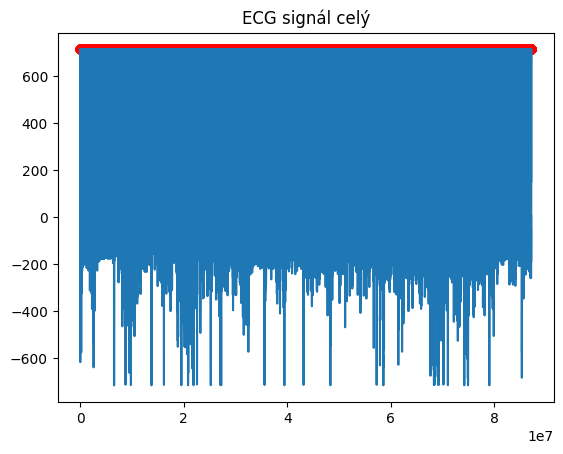

79.70661157024793


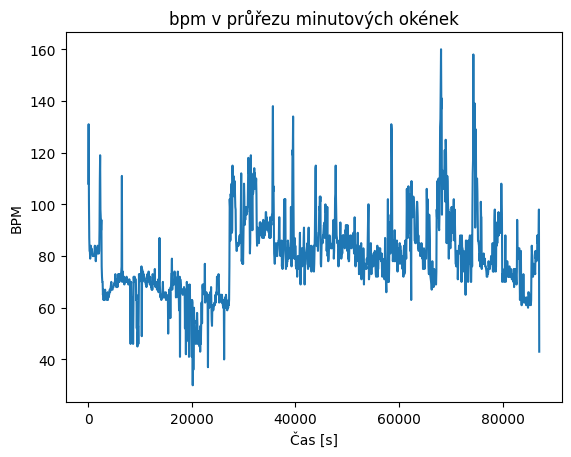

In [35]:
path = "./data_ecg/100001/100001_ECG"
ecg_signal, fields = load_data(path)
fs = fields["fs"]
ecg_signal_filtered = filtering(ecg_signal, fs)
peaks = find_r_peaks(ecg_signal_filtered, fs)
draw_ecg(ecg_signal_filtered, peaks, title="ECG signál celý")
stamp, bpm = count_BPM(ecg_signal_filtered, peaks, fs)
print(np.mean(bpm))
draw_bpm_graph(stamp, bpm, "bpm v průřezu minutových okének")

# Test

In [5]:
def test_file(my_peaks, anoted_peaks):
    anoted = len(anoted_peaks)
    my = len(my_peaks)
    detected = 0
    for peak in anoted_peaks:
        for my_peak in my_peaks:
            if abs(peak - my_peak) < 3:
                detected += 1
                break
    
    res = {
        "anoted": anoted,
        "my_peaks": my,
        "detected": detected,
        "missed": anoted - detected,
        "false positive": my - detected,
        "success": f"{np.round(detected / anoted * 100,2)} %"
    }
    return res

In [6]:
with open("./mit-bih-normal-sinus-rhythm-database-1.0.0/RECORDS", "r") as f:
    records = f.readlines()
records = [record.strip() for record in records]

for record in records:
    path = f"./mit-bih-normal-sinus-rhythm-database-1.0.0/{record}"
    ecg_signal, fields = load_data(path, 0, 100000)
    fs = fields["fs"]
    ecg_signal_filtered = filtering(ecg_signal, fs)
    peaks = find_r_peaks(ecg_signal_filtered, fs)
    truep = wfdb.rdann(path, 'atr', sampfrom=0, sampto=100000).sample
    res = test_file(peaks, truep)
    print(record, res)

16265 {'anoted': 1317, 'my_peaks': 1304, 'detected': 1294, 'missed': 23, 'false positive': 10, 'success': '98.25 %'}
16272 {'anoted': 997, 'my_peaks': 1090, 'detected': 907, 'missed': 90, 'false positive': 183, 'success': '90.97 %'}
16273 {'anoted': 1243, 'my_peaks': 1233, 'detected': 1202, 'missed': 41, 'false positive': 31, 'success': '96.7 %'}
16420 {'anoted': 1154, 'my_peaks': 1166, 'detected': 1121, 'missed': 33, 'false positive': 45, 'success': '97.14 %'}
16483 {'anoted': 1171, 'my_peaks': 1181, 'detected': 749, 'missed': 422, 'false positive': 432, 'success': '63.96 %'}
16539 {'anoted': 1095, 'my_peaks': 1090, 'detected': 1085, 'missed': 10, 'false positive': 5, 'success': '99.09 %'}
16773 {'anoted': 1391, 'my_peaks': 991, 'detected': 958, 'missed': 433, 'false positive': 33, 'success': '68.87 %'}
16786 {'anoted': 964, 'my_peaks': 959, 'detected': 959, 'missed': 5, 'false positive': 0, 'success': '99.48 %'}
16795 {'anoted': 1059, 'my_peaks': 1206, 'detected': 935, 'missed': 124,

# Anomaly detection

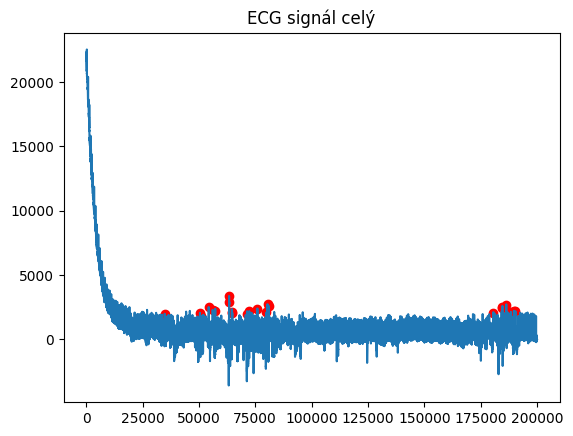

In [75]:
def anomaly_filter(ecg, fs, lowcut=0.5, highcut=40):
    """Filtruje signál pomocí pásmové propusti""" 
    ecg = butter_highpass_filter(ecg, lowcut, fs)
    ecg = butter_lowpass_filter(ecg, highcut, fs)
    ecg = mean_filter(ecg)
    #ecg = np.abs(ecg)
    return np.array(ecg)

def mean_filter(ecg):
    return ecg - np.mean(ecg)

def anomaly_threshold(ecg):
    return np.std(ecg)

def iqr(ecg_signal, peaks):
    peak_values = ecg_signal[peaks]
    Q1 = np.percentile(peak_values, 25)
    Q3 = np.percentile(peak_values, 75)
    IQR = Q3 - Q1
    anomalies = peaks[(peak_values < Q1 - 1.5 * IQR) | (peak_values > Q3 + 1.5 * IQR)]
    return anomalies

def anomaly_detect(ecg, threshold_amplifier = 3):
    threshold = anomaly_threshold(ecg)*threshold_amplifier
    threshold = 3000
    anomaly_indices = [index for index, value in enumerate(ecg) if abs(value) > threshold]
    return anomaly_indices

ecg, fields = load_data("./data_ecg/100001/100001_ECG")
fs = fields["fs"]
ecg = ecg[0:200000]
ecg_filtered = anomaly_filter(ecg, fs)
peaks = find_r_peaks(ecg_filtered, fs)
anomaly = iqr(ecg_filtered, peaks)
draw_ecg(ecg,anomaly, title="ECG signál celý")